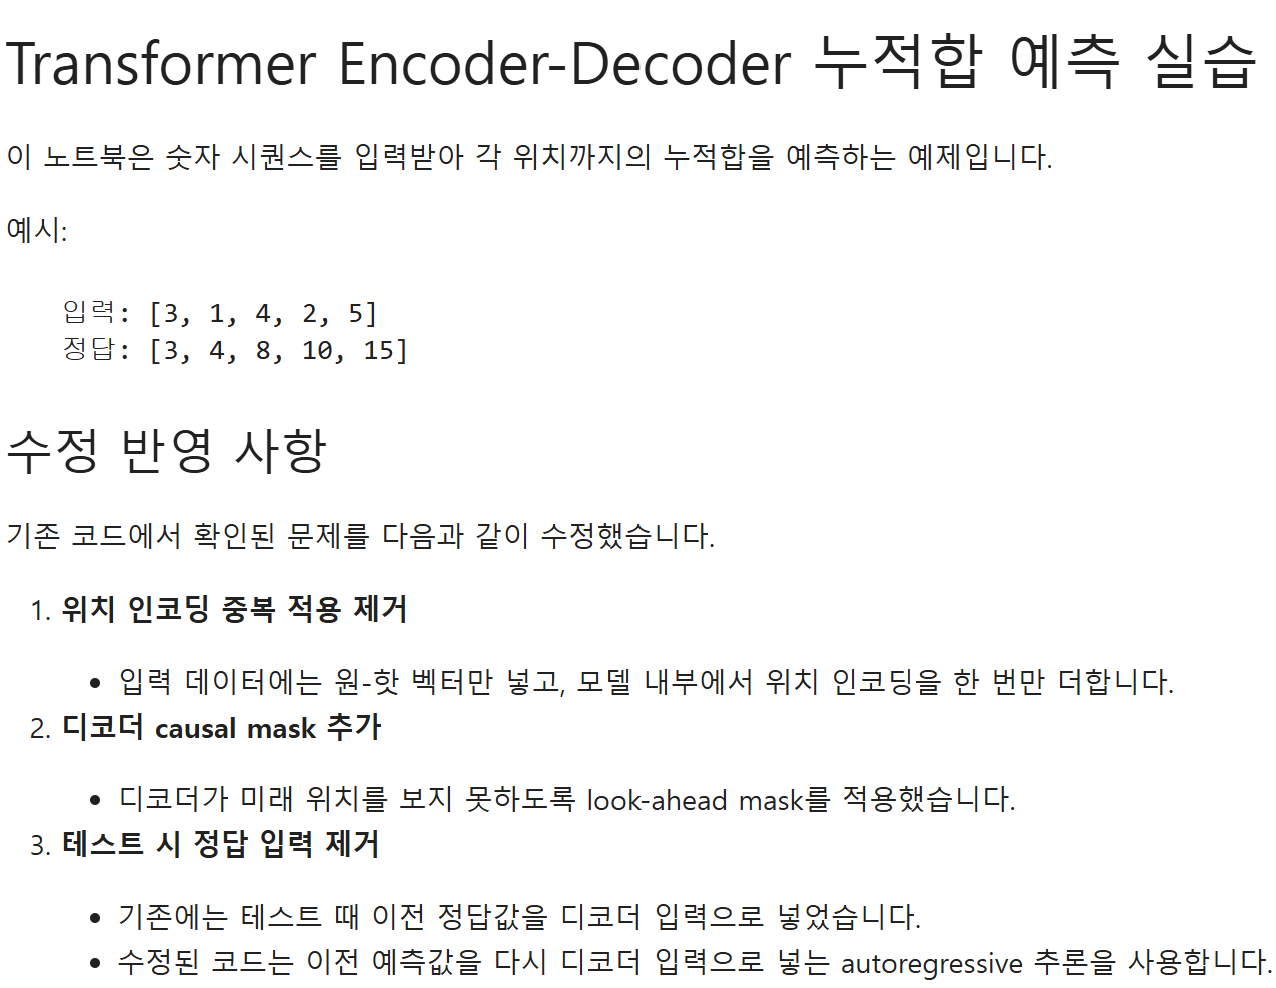

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.layers import Input, Dense, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

np.random.seed(0)
tf.random.set_seed(0)

# 모델이 처리할 수 있는 토큰의 총 개수
vocab_size = 10

# 모델에 한번에 입력되는 시퀀스(문장)의 길이
seq_len = 5

# 각 토큰 하나를 표현하는 임베딩 벡터 차원 수
embed_dim = 10

# 병렬 어텐션 헤드 개수
num_heads = 2

# Position-wise Feed-Forward Network(FFN)
ff_dim = 64

# 학습 데이터 개수
num_samples = 20000

# sin/cos기반 위치 인코딩
def positional_encoding(position: int, d_model: int):
    """
    위치 인코딩 생성 함수

    Parameters
    ----------
    position : int
        최대 시퀀스 길이
    d_model : int
        임베딩 차원

    Returns
    ----------
    Tensor
        shape: (1, position, d_model)
    """
    # pos: 0 ~ position-1 (단어의 인덱스 위치)
    # dim: 0 ~ d_model -1 (하나의 단어(토큰)을 표현하는 임베딩 벡터 내부의 인덱스)
    # arr = np.array([0, 1, 2, 3, 4) -> (5,)
    # vec = arr[:, np.newaxis] -> (5, 1) : 분자
    # np.power() -> (1, 10) : 분모
    # (5, 10) -> 2차원 행렬표
    angle_rads = (
        np.arange(position)[:, np.newaxis] /
        np.power(
            10000,
            (2 * (np.arange(d_model)[np.newaxis, :] // 2)) / d_model
        )
    )

    # 짝수 인덱스에는 sin 적용
    # 0번 인덱스부터 2칸씩 건너뛰며 선택
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

    # 홀수 인덱스에는 cos 적용
    # 1번 인덱스부터 2칸씩 건너뛰며 선택
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    # 배치 차원 추가: (1, position, d_model)
    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32) # (1, 5, 10)

pos_enc = positional_encoding(seq_len, embed_dim)
print(pos_enc.shape)

# 데이터 생성
def generate_cumsum_data(num_samples=10000, seq_len=5, max_val=10):
    """
    랜덤 숫자 시퀀스 X와 누적합 y를 생성합니다.

    예)
    X = [3, 1, 4, 2, 5]
    y = [3, 4, 8, 10, 15]
    """
    X = np.random.randint(0, max_val, (num_samples, seq_len)) # 0 부터 9(index 기준)까지 (10000, 5)개의
    y = np.cumsum(X, axis=1) # cumsum : 누적합, axis =1 은 '행'방향
    return X, y

X_train, y_train = generate_cumsum_data(
    num_samples=num_samples,
    seq_len=seq_len,
    max_val=vocab_size
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("입력 예시:", X_train[0]) # 1문장 당 5개 토큰
print("정답 예시:", y_train[0]) # 1문장 당 5개 토큰

# 인코더 입력 값 : 원-핫 인코딩만 수행
# shape : (batch, seq_len, vocab_size)
X_onehot = tf.one_hot(X_train, depth=vocab_size)

# 디코더 입력 값 : 정답 누적합을 한칸 오른쪽으로 이동
# 맨 앞의 0은 토큰 시작 역할
y_shifted = np.concatenate(
    [
        np.zeros((y_train.shape[0], 1)), # sos : 0으로 채워진 세로 열 생성
        y_train[:, :-1] # 정답
    ],
    axis=1
)[..., np.newaxis].astype(np.float32)

# 모델 출력 정답
y_target = y_train[..., np.newaxis].astype(np.float32)

print("X_onehot shape:", X_onehot.shape)
print("y_shifted shape:", y_shifted.shape)
print("y_target shape:", y_target.shape)
print("정답 예시:", y_train[0])
print("디코더 입력 예시:", y_shifted[0].squeeze())

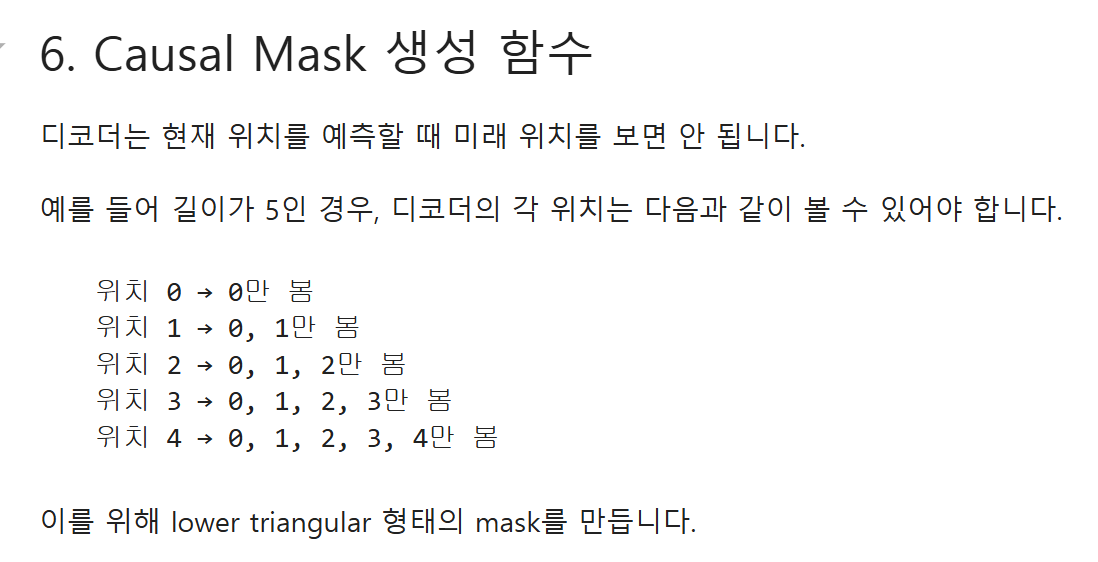

In [ ]:
def create_causal_attention_mask(seq_len: int):
    """
    디코더 self-attention용 causal mask 생성

    Keras MultiHeadAttention의 attention_mask는
    1이면 attention 가능, 0이면 attention 불가능입니다.

    반환 shape: (1, seq_len, seq_len)
    """
    mask = np.tril(np.ones((seq_len, seq_len), dtype=np.int32))
    return tf.constant(mask[np.newaxis, :, :])

causal_mask = create_causal_attention_mask(seq_len)
print(causal_mask.numpy().squeeze())

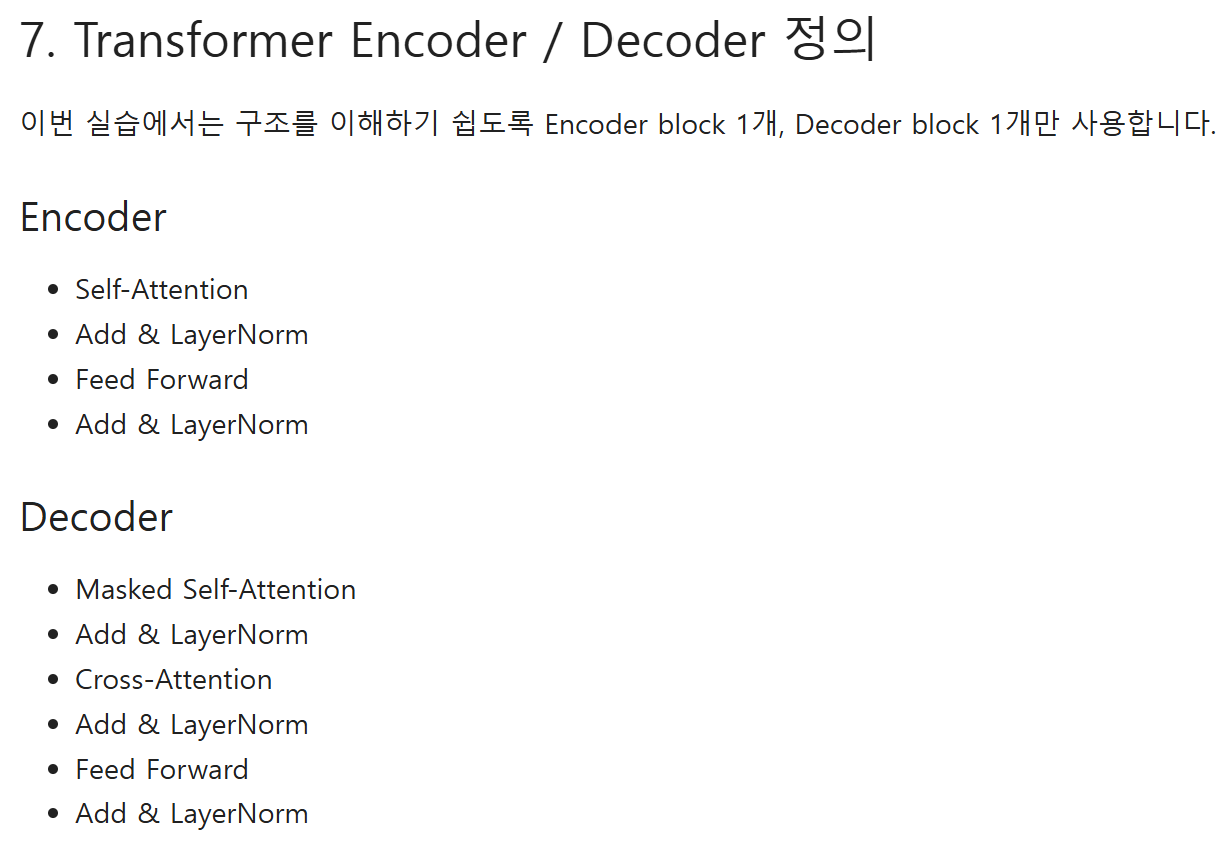

In [ ]:
def transformer_encoder(x, d_model, heads, dff):
    """Transformer Encoder Block"""

    # d_model : 전체 임베딩 차원 수, heads : 병렬로 나누어 연산할 어텐션 헤드의 개수 => key_dim : 각 어텐션 헤드가 담당할 벡터의 차원 크기
    key_dim = d_model // heads

    # Encoder Self-Attention 
    # 입력된 시퀀스 x 본인끼리, 서로 어떤 단어와 연관성이 높은지 계산
    attn = MultiHeadAttention( #(query, value, key) -> (x, x, x)
        num_heads=heads,
        key_dim=key_dim
    )(x, x)

    # Residual Connection + Layer Normalization
    # Add()([x, attn]) : 원본 x + 어텐션 attn
    # LayerNormailzation : 평균을 0, 표준편차를 1로 맞추어 데이터 분포를 안정화
    x = LayerNormalization(epsilon=1e-6)(Add()([x, attn]))

    # Position-wise Feed Forward Network
    ffn = Dense(dff, activation='relu')(x)
    ffn = Dense(d_model)(ffn)

    return LayerNormalization(epsilon=1e-6)(Add()([x, ffn]))

def transformer_decoder(x, enc_out, d_model, heads, dff, causal_mask):
    """Transformer Decoder Block"""

    key_dim = d_model // heads

    # 1) Masked Self-Attention
    # causal_mask를 넣어 미래 위치를 보지 못하게 합니다
    attn1 = MultiHeadAttention(
        num_heads=heads,
        key_dim=key_dim
    )(x, x, attention_mask=causal_mask)

    x = LayerNormalization(epsilon=1e-6)(Add()([x, attn1]))

    # 2) Cross-Attention
    # Query -> decoder쪽 x
    # Key/Value -> encoder쪽 출력 -> enc_out
    attn2 = MultiHeadAttention(
        num_heads=heads,
        key_dim=key_dim
    )(query=x, key=enc_out, value=enc_out)

    x = LayerNormalization(epsilon=1e-6)(Add()([x, attn2]))

    # 3) Feed Forward Network
    ffn = Dense(dff, activation='relu')(x)
    ffn = Dense(d_model)(ffn)

    return LayerNormalization(epsilon=1e-6)(Add()([x, ffn]))

# 인코더 입력
enc_inputs = Input(shape=(seq_len, embed_dim), name='encoder_input')

# 디코더 원시 입력
# shape(batch, seq_len, 1)
dec_inputs_raw = Input(shape=(seq_len, 1), name='decoder_input_raw')

# 디코더 입력을 embed_dim 차원으로 변환
dec_embed = Dense(embed_dim, name='decoder_embed')(dec_inputs_raw)

# 위치 인코딩(한번만 더해주면 됨)
enc_x = enc_inputs + pos_enc
dec_x = dec_embed + pos_enc

# Encoder / Decoder
enc_out = transformer_encoder(enc_x, embed_dim, num_heads, ff_dim)
dec_out = transformer_decoder(dec_x, enc_out, embed_dim, num_heads, ff_dim, causal_mask)

# 각 위치의 누적합 예측 -> 출력차원 1
outputs = Dense(1, name='output')(dec_out)

model = Model(inputs=[enc_inputs, dec_inputs_raw], outputs=outputs)
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

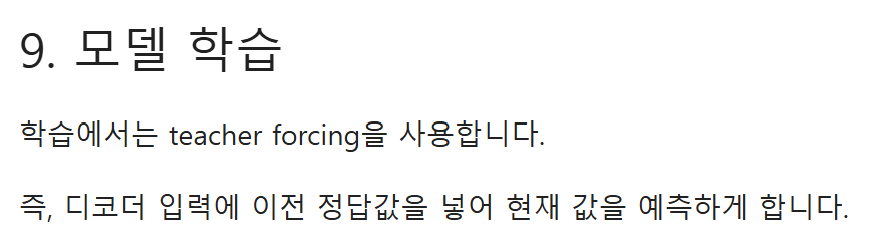

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        'best_transformer_cumsum.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

history = model.fit(
    [X_onehot, y_shifted],
    y_target,
    batch_size=64,
    epochs=80,
    validation_split=0.2,
    callbacks=callbacks
)

print("모델 저장 완료 : best_transformer_cumsum.keras")

In [ ]:
# 시각화

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='train mae')
plt.plot(history.history['val_mae'], label='validation mae')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

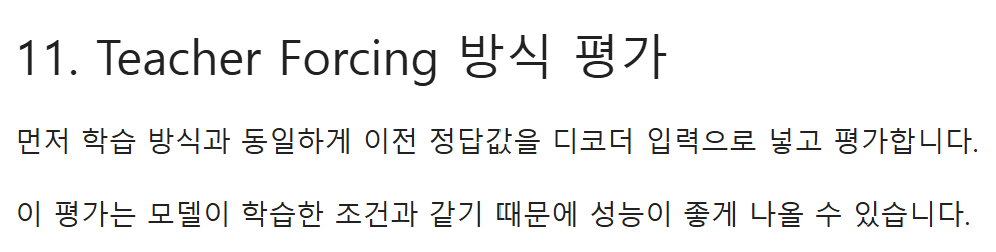

In [ ]:
X_test, y_test = generate_cumsum_data(num_samples=20, seq_len=seq_len, max_val=vocab_size)

X_test_onehot = tf.one_hot(X_test, depth=vocab_size)

# teacher Forcing방식 평가
y_test_shifted = np.concatenate(
    [
        np.zeros((y_test.shape[0], 1)),
        y_test[:, :-1]
    ],
    axis=1
)[..., np.newaxis].astype(np.float32)

y_pred_tf = model.predict([X_test_onehot, y_test_shifted], verbose=0)
y_pred_tf_rounded = np.round(y_pred_tf.squeeze()).astype(int)

matches_tf = np.all(y_pred_tf_rounded == y_test, axis=1)
accuracy_tf = np.mean(matches_tf)

for i in range(len(X_test)):
    print("입력 :", X_test[i])
    print("실제 :", y_test[i])
    print("예측 :", y_pred_tf_rounded[i])
    print("일치 :", matches_tf[i])
    print()

print(f"Teacher Forcing Exact Match Accuracy: {accuracy_tf * 100:.2f}%")

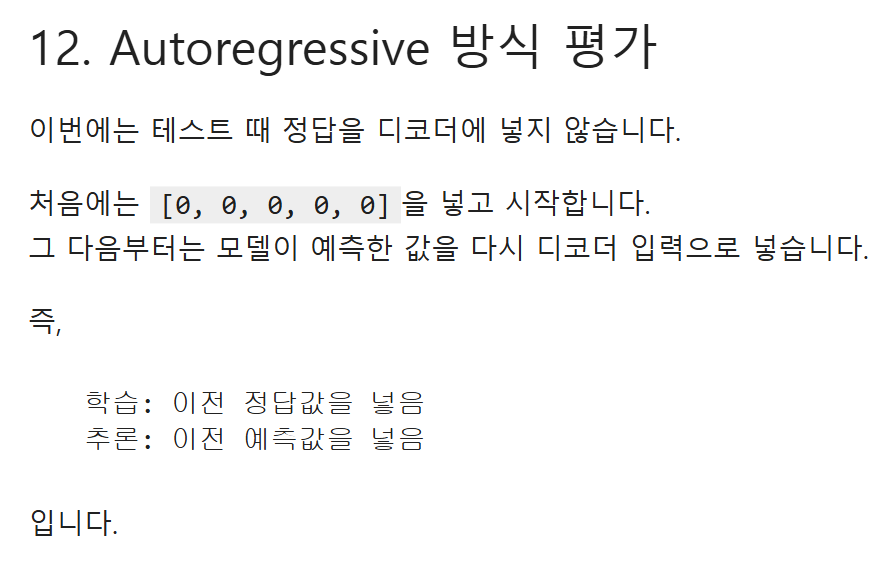

In [ ]:
def autoregressive_predict(model, X_int, seq_len, vocab_size):
    """
    이전 정답을 사용하지 않고, 이전 예측값을 다시 디코더 입력으로 넣어 예측합니다.

    Parameters
    ----------
    model : keras Model
        학습된 Transformer Encoder-Decoder 모델
    X_int : ndarray
        정수 입력 시퀀스, shape: (batch, seq_len)
    seq_len : int
        시퀀스 길이
    vocab_size : int
        원-핫 인코딩 깊이

    Returns
    -------
    ndarray
        예측 누적합, shape: (batch, seq_len)
    """

    X_onehot = tf.one_hot(X_int, depth=vocab_size)

    # 처음 디코더 입력은 모두 0
    dec_input = np.zeros((X_int.shape[0], seq_len, 1), dtype=np.float32)

    predictions = np.zeros((X_int.shape[0], seq_len), dtype=np.float32)

    for t in range(seq_len):
        # 현재까지 채워진 decoder input으로 전체 시퀀스를 예측
        pred = model.predict([X_onehot, dec_input], verbose=0)

        # t번째 위치의 예측값만 사용
        current_pred = pred[:, t, 0]

        # 누적합은 정수이므로 반올림
        current_pred_rounded = np.round(current_pred)

        predictions[:, t] = current_pred_rounded

        # 다음 위치의 decoder input에는 현재 예측값을 넣음
        if t + 1 < seq_len:
            dec_input[:, t + 1, 0] = current_pred_rounded

    return predictions.astype(int)


y_pred_ar = autoregressive_predict(model, X_test, seq_len, vocab_size)

matches_ar = np.all(y_pred_ar == y_test, axis=1)
accuracy_ar = np.mean(matches_ar)

for i in range(len(X_test)):
    print("입력:", X_test[i])
    print("실제:", y_test[i])
    print("예측:", y_pred_ar[i])
    print("일치:", matches_ar[i])
    print()

print(f"Autoregressive Exact Match Accuracy: {accuracy_ar * 100:.2f}%")

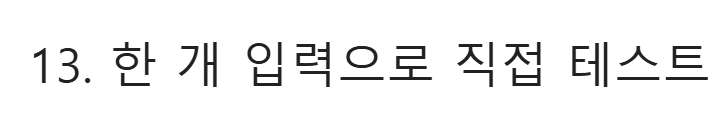

In [ ]:
sample = np.array([[3, 1, 4, 2, 5]])
sample_answer = np.cumsum(sample, axis=1)

sample_pred = autoregressive_predict(model, sample, seq_len, vocab_size)

print("입력:", sample[0])
print("정답:", sample_answer[0])
print("예측:", sample_pred[0])

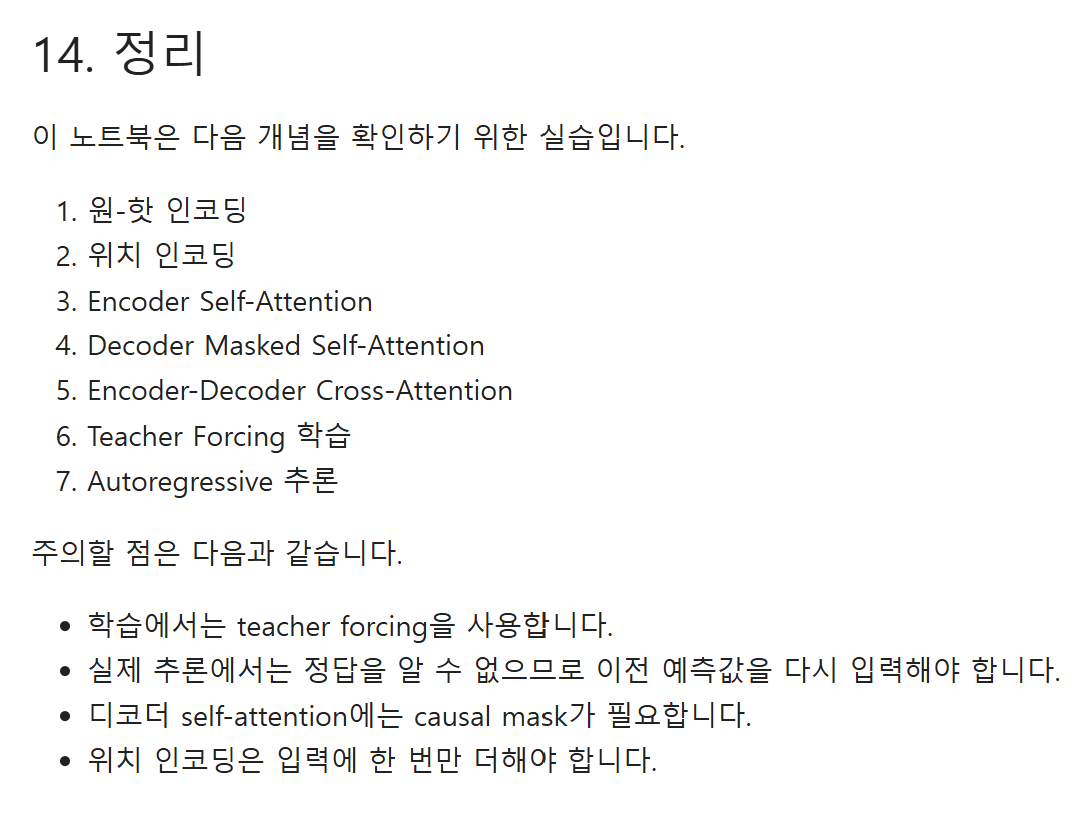